In [6]:
import pandas as pd

file_path = r"..\..\data\raw\ev_charging_dataset.xlsx"

stations = pd.read_excel(file_path, sheet_name="stations")
chargers = pd.read_excel(file_path, sheet_name="chargers")
sessions = pd.read_excel(file_path, sheet_name="sessions")

In [7]:
print("Stations:", stations.shape)
print("Chargers:", chargers.shape)
print("Sessions:", sessions.shape)

Stations: (33, 5)
Chargers: (199, 5)
Sessions: (294024, 15)


In [8]:
chargers.head()

,charger_id,station_id,charger_type,max_power_kW,installation_date
0,STN_001_CH_01,STN_001,DC_50kW,50,2022-06-07
1,STN_001_CH_02,STN_001,DC_150kW,150,2022-12-22
2,STN_001_CH_03,STN_001,DC_150kW,150,2022-10-21
3,STN_001_CH_04,STN_001,DC_50kW,50,2022-12-08
4,STN_002_CH_01,STN_002,DC_50kW,50,2022-07-09


In [9]:
chargers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   charger_id         199 non-null    object        
 1   station_id         199 non-null    object        
 2   charger_type       199 non-null    object        
 3   max_power_kW       199 non-null    int64         
 4   installation_date  199 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 7.9+ KB


In [10]:
chargers["charger_type"].value_counts()

charger_type
DC_50kW     95
DC_150kW    69
DC_300kW    35
Name: count, dtype: int64

In [11]:
sessions.head()

,session_id,station_id,charger_id,charger_type,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh,price_per_kwh,total_cost,payment_method,user_type,customer_id,station_region,year
0,S_00000001,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 08:30:00,2022-01-01 08:56:00,26,56.9,0.47,26.74,app,fleet,CUST_00134,North West,2022
1,S_00000002,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 09:20:00,2022-01-01 09:41:00,21,40.7,0.46,18.72,app,delivery,CUST_00195,North West,2022
2,S_00000003,STN_001,STN_001_CH_04,DC_50kW,2022-01-01 09:00:00,2022-01-01 09:48:00,48,30.9,0.47,14.52,rfid,public,CUST_01935,North West,2022
3,S_00000004,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 23:20:00,2022-01-02 00:01:00,41,28.4,0.45,12.78,rfid,public,CUST_00036,North West,2022
4,S_00000005,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 16:10:00,2022-01-01 17:00:00,50,31.7,0.56,17.75,rfid,taxi,CUST_00011,North West,2022


In [12]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294024 entries, 0 to 294023
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   session_id                294024 non-null  object        
 1   station_id                294024 non-null  object        
 2   charger_id                294024 non-null  object        
 3   charger_type              294024 non-null  object        
 4   start_timestamp           294024 non-null  datetime64[ns]
 5   end_timestamp             294024 non-null  datetime64[ns]
 6   session_duration_minutes  294024 non-null  int64         
 7   energy_kwh                294024 non-null  float64       
 8   price_per_kwh             294024 non-null  float64       
 9   total_cost                294024 non-null  float64       
 10  payment_method            294024 non-null  object        
 11  user_type                 294024 non-null  object        
 12  cu

In [13]:
sessions[[
    "charger_id",
    "charger_type",
    "start_timestamp",
    "end_timestamp",
    "session_duration_minutes",
    "energy_kwh"
]].head()

,charger_id,charger_type,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh
0,STN_001_CH_02,DC_150kW,2022-01-01 08:30:00,2022-01-01 08:56:00,26,56.9
1,STN_001_CH_02,DC_150kW,2022-01-01 09:20:00,2022-01-01 09:41:00,21,40.7
2,STN_001_CH_04,DC_50kW,2022-01-01 09:00:00,2022-01-01 09:48:00,48,30.9
3,STN_001_CH_01,DC_50kW,2022-01-01 23:20:00,2022-01-02 00:01:00,41,28.4
4,STN_001_CH_01,DC_50kW,2022-01-01 16:10:00,2022-01-01 17:00:00,50,31.7


In [14]:
charger_usage = (
    sessions.groupby("charger_id")
    .agg(
        total_sessions=("session_id", "count"),
        total_charging_minutes=("session_duration_minutes", "sum"),
        total_energy_kwh=("energy_kwh", "sum")
    )
    .reset_index()
)

charger_usage.head()

,charger_id,total_sessions,total_charging_minutes,total_energy_kwh
0,STN_001_CH_01,3731,184859,123295.5
1,STN_001_CH_02,3706,90590,181117.4
2,STN_001_CH_03,3877,94833,189580.8
3,STN_001_CH_04,3848,190348,126957.9
4,STN_002_CH_01,3084,152559,101707.9


In [15]:
charger_usage["total_charging_hours"] = (
    charger_usage["total_charging_minutes"] / 60
)

charger_usage.head()

,charger_id,total_sessions,total_charging_minutes,total_energy_kwh,total_charging_hours
0,STN_001_CH_01,3731,184859,123295.5,3080.983333
1,STN_001_CH_02,3706,90590,181117.4,1509.833333
2,STN_001_CH_03,3877,94833,189580.8,1580.550000
3,STN_001_CH_04,3848,190348,126957.9,3172.466667
4,STN_002_CH_01,3084,152559,101707.9,2542.650000


In [16]:
print("Session start:", sessions["start_timestamp"].min())
print("Session end:", sessions["end_timestamp"].max())

Session start: 2022-01-01 01:30:00
Session end: 2025-01-01 00:42:00


In [17]:
print("Earliest installation:", chargers["installation_date"].min())
print("Latest installation:", chargers["installation_date"].max())

Earliest installation: 2022-01-04 00:00:00
Latest installation: 2024-12-28 00:00:00


In [18]:
charger_performance = chargers.merge(
    charger_usage,
    on="charger_id",
    how="left"
)

charger_performance.head()

,charger_id,station_id,charger_type,max_power_kW,installation_date,total_sessions,total_charging_minutes,total_energy_kwh,total_charging_hours
0,STN_001_CH_01,STN_001,DC_50kW,50,2022-06-07,3731,184859,123295.5,3080.983333
1,STN_001_CH_02,STN_001,DC_150kW,150,2022-12-22,3706,90590,181117.4,1509.833333
2,STN_001_CH_03,STN_001,DC_150kW,150,2022-10-21,3877,94833,189580.8,1580.550000
3,STN_001_CH_04,STN_001,DC_50kW,50,2022-12-08,3848,190348,126957.9,3172.466667
4,STN_002_CH_01,STN_002,DC_50kW,50,2022-07-09,3084,152559,101707.9,2542.650000


In [19]:
print("Rows:", len(charger_performance))
print(
    "Chargers with no sessions:",
    charger_performance["total_sessions"].isna().sum()
)

Rows: 199
Chargers with no sessions: 0


In [20]:
charger_performance[
    [
        "charger_id",
        "charger_type",
        "max_power_kW",
        "installation_date",
        "total_sessions",
        "total_charging_hours",
        "total_energy_kwh"
    ]
].head()

,charger_id,charger_type,max_power_kW,installation_date,total_sessions,total_charging_hours,total_energy_kwh
0,STN_001_CH_01,DC_50kW,50,2022-06-07,3731,3080.983333,123295.5
1,STN_001_CH_02,DC_150kW,150,2022-12-22,3706,1509.833333,181117.4
2,STN_001_CH_03,DC_150kW,150,2022-10-21,3877,1580.550000,189580.8
3,STN_001_CH_04,DC_50kW,50,2022-12-08,3848,3172.466667,126957.9
4,STN_002_CH_01,DC_50kW,50,2022-07-09,3084,2542.650000,101707.9


In [21]:
charger_performance["avg_delivered_power_kW"] = (
    charger_performance["total_energy_kwh"]
    / charger_performance["total_charging_hours"]
)

In [22]:
charger_performance[
    [
        "charger_id",
        "charger_type",
        "max_power_kW",
        "avg_delivered_power_kW"
    ]
].head()

,charger_id,charger_type,max_power_kW,avg_delivered_power_kW
0,STN_001_CH_01,DC_50kW,50,40.018230
1,STN_001_CH_02,DC_150kW,150,119.958538
2,STN_001_CH_03,DC_150kW,150,119.946095
3,STN_001_CH_04,DC_50kW,50,40.018671
4,STN_002_CH_01,DC_50kW,50,40.000747


In [23]:
charger_performance["capacity_utilisation_pct"] = (
    charger_performance["avg_delivered_power_kW"]
    / charger_performance["max_power_kW"]
) * 100

In [24]:
charger_performance[
    [
        "charger_id",
        "charger_type",
        "max_power_kW",
        "avg_delivered_power_kW",
        "capacity_utilisation_pct"
    ]
].head()

,charger_id,charger_type,max_power_kW,avg_delivered_power_kW,capacity_utilisation_pct
0,STN_001_CH_01,DC_50kW,50,40.018230,80.036460
1,STN_001_CH_02,DC_150kW,150,119.958538,79.972359
2,STN_001_CH_03,DC_150kW,150,119.946095,79.964063
3,STN_001_CH_04,DC_50kW,50,40.018671,80.037342
4,STN_002_CH_01,DC_50kW,50,40.000747,80.001495


In [25]:
charger_performance["capacity_utilisation_pct"].describe()

count    199.000000
mean      79.524732
std        0.942477
min       77.191954
25%       79.756259
50%       79.914215
75%       80.024266
max       80.285640
Name: capacity_utilisation_pct, dtype: float64

In [26]:
charger_performance.groupby("charger_type")[
    "capacity_utilisation_pct"
].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
charger_type,,,,,
DC_150kW,69,79.955892,79.941952,79.520016,80.285640
DC_300kW,35,77.515857,77.521263,77.191954,77.851741
DC_50kW,95,79.951685,79.961095,79.546371,80.264639


In [27]:
observation_end = sessions["end_timestamp"].max()

print("Observation end:", observation_end)

Observation end: 2025-01-01 00:42:00


In [28]:
charger_performance["available_days"] = (
    observation_end - charger_performance["installation_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [29]:
charger_performance["available_hours"] = (
    charger_performance["available_days"] * 24
)

In [30]:
charger_performance["time_utilisation_pct"] = (
    charger_performance["total_charging_hours"]
    / charger_performance["available_hours"]
) * 100

In [31]:
charger_performance[
    [
        "charger_id",
        "installation_date",
        "total_charging_hours",
        "available_hours",
        "time_utilisation_pct"
    ]
].head()

,charger_id,installation_date,total_charging_hours,available_hours,time_utilisation_pct
0,STN_001_CH_01,2022-06-07,3080.983333,22536.7,13.670960
1,STN_001_CH_02,2022-12-22,1509.833333,17784.7,8.489507
2,STN_001_CH_03,2022-10-21,1580.550000,19272.7,8.200979
3,STN_001_CH_04,2022-12-08,3172.466667,18120.7,17.507418
4,STN_002_CH_01,2022-07-09,2542.650000,21768.7,11.680302


In [32]:
charger_performance["time_utilisation_pct"].describe()

count    199.000000
mean      16.430917
std       32.503399
min        2.341732
25%        5.459970
50%        8.489507
75%       14.648518
max      342.726646
Name: time_utilisation_pct, dtype: float64

In [33]:
print(
    "Minimum utilisation:",
    charger_performance["time_utilisation_pct"].min()
)

print(
    "Maximum utilisation:",
    charger_performance["time_utilisation_pct"].max()
)

Minimum utilisation: 2.3417323302597732
Maximum utilisation: 342.72664598414343


In [34]:
charger_performance.groupby("charger_type")[
    ["time_utilisation_pct", "capacity_utilisation_pct"]
].agg(["mean", "median", "min", "max"])

time_utilisation_pct                                   \
                             mean     median       min         max   
charger_type                                                         
DC_150kW                13.631886   5.929121  2.978884  177.274821   
DC_300kW                17.071908   4.480470  2.341732  342.726646   
DC_50kW                 18.227743  12.004604  5.965386  122.440490   

             capacity_utilisation_pct                                   
                                 mean     median        min        max  
charger_type                                                            
DC_150kW                    79.955892  79.941952  79.520016  80.285640  
DC_300kW                    77.515857  77.521263  77.191954  77.851741  
DC_50kW                     79.951685  79.961095  79.546371  80.264639

In [35]:
charger_performance[
    charger_performance["time_utilisation_pct"] > 100
][
    [
        "charger_id",
        "installation_date",
        "total_charging_hours",
        "available_hours",
        "time_utilisation_pct"
    ]
].sort_values(
    "time_utilisation_pct",
    ascending=False
).head(10)

,charger_id,installation_date,total_charging_hours,available_hours,time_utilisation_pct
174,STN_029_CH_01,2024-12-28,331.416667,96.7,342.726646
121,STN_021_CH_03,2024-12-26,256.516667,144.7,177.274821
139,STN_024_CH_01,2024-12-24,301.050000,192.7,156.227296
137,STN_023_CH_07,2024-12-14,529.800000,432.7,122.440490
162,STN_027_CH_01,2024-12-13,516.483333,456.7,113.090285


In [36]:
session_check = sessions[
    ["charger_id", "start_timestamp", "end_timestamp"]
].merge(
    chargers[
        ["charger_id", "installation_date"]
    ],
    on="charger_id",
    how="left"
)

In [37]:
session_check["before_installation"] = (
    session_check["start_timestamp"].dt.normalize()
    < session_check["installation_date"]
)

session_check["before_installation"].value_counts()

before_installation
False    205558
True      88466
Name: count, dtype: int64

In [38]:
overlap_check = sessions[
    ["charger_id", "start_timestamp", "end_timestamp"]
].sort_values(
    ["charger_id", "start_timestamp"]
).copy()

overlap_check["previous_end"] = (
    overlap_check.groupby("charger_id")["end_timestamp"].shift(1)
)

overlap_check["overlap"] = (
    overlap_check["start_timestamp"] < overlap_check["previous_end"]
)

print("Overlapping sessions:", overlap_check["overlap"].sum())

Overlapping sessions: 24425


In [39]:
def calculate_unique_hours(group):
    intervals = group[
        ["start_timestamp", "end_timestamp"]
    ].sort_values("start_timestamp")

    total_seconds = 0

    current_start = None
    current_end = None

    for start, end in intervals.itertuples(index=False):
        if current_start is None:
            current_start = start
            current_end = end

        elif start <= current_end:
            current_end = max(current_end, end)

        else:
            total_seconds += (current_end - current_start).total_seconds()
            current_start = start
            current_end = end

    if current_start is not None:
        total_seconds += (current_end - current_start).total_seconds()

    return total_seconds / 3600

In [41]:
unique_charging_hours = (
    sessions.groupby("charger_id")
    .apply(calculate_unique_hours)
    .reset_index(name="unique_charging_hours")
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26100\2115976584.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_unique_hours)


In [42]:
unique_charging_hours.head()

,charger_id,unique_charging_hours
0,STN_001_CH_01,2822.633333
1,STN_001_CH_02,1442.016667
2,STN_001_CH_03,1515.200000
3,STN_001_CH_04,2911.416667
4,STN_002_CH_01,2379.700000


In [43]:
observed_window = (
    sessions.groupby("charger_id")
    .agg(
        first_session_start=("start_timestamp", "min"),
        last_session_end=("end_timestamp", "max")
    )
    .reset_index()
)

observed_window["observed_hours"] = (
    observed_window["last_session_end"]
    - observed_window["first_session_start"]
).dt.total_seconds() / 3600

observed_window.head()

,charger_id,first_session_start,last_session_end,observed_hours
0,STN_001_CH_01,2022-01-01 16:10:00,2024-12-31 15:51:00,26279.683333
1,STN_001_CH_02,2022-01-01 01:30:00,2024-12-31 17:23:00,26295.883333
2,STN_001_CH_03,2022-01-01 11:30:00,2024-12-31 17:34:00,26286.066667
3,STN_001_CH_04,2022-01-01 07:20:00,2024-12-31 17:41:00,26290.350000
4,STN_002_CH_01,2022-01-03 10:00:00,2024-12-31 18:31:00,26240.516667


In [44]:
time_utilisation = unique_charging_hours.merge(
    observed_window,
    on="charger_id",
    how="left"
)

time_utilisation.head()

,charger_id,unique_charging_hours,first_session_start,last_session_end,observed_hours
0,STN_001_CH_01,2822.633333,2022-01-01 16:10:00,2024-12-31 15:51:00,26279.683333
1,STN_001_CH_02,1442.016667,2022-01-01 01:30:00,2024-12-31 17:23:00,26295.883333
2,STN_001_CH_03,1515.200000,2022-01-01 11:30:00,2024-12-31 17:34:00,26286.066667
3,STN_001_CH_04,2911.416667,2022-01-01 07:20:00,2024-12-31 17:41:00,26290.350000
4,STN_002_CH_01,2379.700000,2022-01-03 10:00:00,2024-12-31 18:31:00,26240.516667


In [45]:
time_utilisation["observed_time_utilisation_pct"] = (
    time_utilisation["unique_charging_hours"]
    / time_utilisation["observed_hours"]
) * 100

In [46]:
time_utilisation[
    [
        "charger_id",
        "unique_charging_hours",
        "observed_hours",
        "observed_time_utilisation_pct"
    ]
].head()

,charger_id,unique_charging_hours,observed_hours,observed_time_utilisation_pct
0,STN_001_CH_01,2822.633333,26279.683333,10.740743
1,STN_001_CH_02,1442.016667,26295.883333,5.483811
2,STN_001_CH_03,1515.200000,26286.066667,5.764271
3,STN_001_CH_04,2911.416667,26290.350000,11.074089
4,STN_002_CH_01,2379.700000,26240.516667,9.068800


In [47]:
print(
    "Minimum:",
    time_utilisation["observed_time_utilisation_pct"].min()
)

print(
    "Maximum:",
    time_utilisation["observed_time_utilisation_pct"].max()
)

Minimum: 2.1574599307115396
Maximum: 11.56004745391495


In [48]:
final_charger_performance = charger_performance.merge(
    time_utilisation[
        [
            "charger_id",
            "unique_charging_hours",
            "observed_hours",
            "observed_time_utilisation_pct"
        ]
    ],
    on="charger_id",
    how="left"
)

In [49]:
final_charger_performance.shape

(199, 17)

In [50]:
final_charger_performance = final_charger_performance[
    [
        "charger_id",
        "station_id",
        "charger_type",
        "max_power_kW",
        "installation_date",
        "total_sessions",
        "total_charging_hours",
        "unique_charging_hours",
        "total_energy_kwh",
        "avg_delivered_power_kW",
        "capacity_utilisation_pct",
        "observed_hours",
        "observed_time_utilisation_pct"
    ]
]

In [51]:
final_charger_performance.head()

,charger_id,station_id,charger_type,max_power_kW,installation_date,total_sessions,total_charging_hours,unique_charging_hours,total_energy_kwh,avg_delivered_power_kW,capacity_utilisation_pct,observed_hours,observed_time_utilisation_pct
0,STN_001_CH_01,STN_001,DC_50kW,50,2022-06-07,3731,3080.983333,2822.633333,123295.5,40.018230,80.036460,26279.683333,10.740743
1,STN_001_CH_02,STN_001,DC_150kW,150,2022-12-22,3706,1509.833333,1442.016667,181117.4,119.958538,79.972359,26295.883333,5.483811
2,STN_001_CH_03,STN_001,DC_150kW,150,2022-10-21,3877,1580.550000,1515.200000,189580.8,119.946095,79.964063,26286.066667,5.764271
3,STN_001_CH_04,STN_001,DC_50kW,50,2022-12-08,3848,3172.466667,2911.416667,126957.9,40.018671,80.037342,26290.350000,11.074089
4,STN_002_CH_01,STN_002,DC_50kW,50,2022-07-09,3084,2542.650000,2379.700000,101707.9,40.000747,80.001495,26240.516667,9.068800


In [52]:
final_charger_performance.isna().sum()

charger_id                       0
station_id                       0
charger_type                     0
max_power_kW                     0
installation_date                0
total_sessions                   0
total_charging_hours             0
unique_charging_hours            0
total_energy_kwh                 0
avg_delivered_power_kW           0
capacity_utilisation_pct         0
observed_hours                   0
observed_time_utilisation_pct    0
dtype: int64

In [53]:
print(
    "Duplicate charger IDs:",
    final_charger_performance["charger_id"].duplicated().sum()
)

Duplicate charger IDs: 0


In [54]:
top_time_utilisation = final_charger_performance.sort_values(
    "observed_time_utilisation_pct",
    ascending=False
)

top_time_utilisation[
    [
        "charger_id",
        "station_id",
        "charger_type",
        "max_power_kW",
        "total_sessions",
        "total_energy_kwh",
        "observed_time_utilisation_pct"
    ]
].head(10)

,charger_id,station_id,charger_type,max_power_kW,total_sessions,total_energy_kwh,observed_time_utilisation_pct
181,STN_030_CH_03,STN_030,DC_50kW,50,1349,44559.6,11.560047
179,STN_030_CH_01,STN_030,DC_50kW,50,1333,43952.6,11.514648
82,STN_014_CH_03,STN_014,DC_50kW,50,2628,86497.4,11.383455
128,STN_022_CH_02,STN_022,DC_50kW,50,1312,43425.8,11.238657
102,STN_018_CH_01,STN_018,DC_50kW,50,1284,42355.0,11.114594
3,STN_001_CH_04,STN_001,DC_50kW,50,3848,126957.9,11.074089
35,STN_007_CH_02,STN_007,DC_50kW,50,3839,126245.6,11.003227
127,STN_022_CH_01,STN_022,DC_50kW,50,1268,41759.2,10.982258
37,STN_007_CH_04,STN_007,DC_50kW,50,3817,126216.4,10.970018
105,STN_018_CH_04,STN_018,DC_50kW,50,1272,41902.5,10.916084


In [55]:
bottom_time_utilisation = final_charger_performance.sort_values(
    "observed_time_utilisation_pct",
    ascending=True
)

bottom_time_utilisation[
    [
        "charger_id",
        "station_id",
        "charger_type",
        "max_power_kW",
        "total_sessions",
        "total_energy_kwh",
        "observed_time_utilisation_pct"
    ]
].head(10)

,charger_id,station_id,charger_type,max_power_kW,total_sessions,total_energy_kwh,observed_time_utilisation_pct
147,STN_025_CH_02,STN_025,DC_300kW,300,598,44921.5,2.157460
165,STN_027_CH_04,STN_027,DC_300kW,300,593,44932.8,2.174372
131,STN_023_CH_01,STN_023,DC_300kW,300,620,46923.8,2.251643
60,STN_011_CH_02,STN_011,DC_300kW,300,1233,93278.3,2.260870
22,STN_005_CH_01,STN_005,DC_300kW,300,1859,140534.2,2.263209
15,STN_004_CH_02,STN_004,DC_300kW,300,1851,140181.0,2.267465
64,STN_011_CH_06,STN_011,DC_300kW,300,1255,94820.9,2.298745
148,STN_025_CH_03,STN_025,DC_300kW,300,632,47575.4,2.299693
21,STN_004_CH_08,STN_004,DC_300kW,300,1901,143748.2,2.303475
75,STN_013_CH_04,STN_013,DC_300kW,300,1266,95447.5,2.315839


In [56]:
charger_type_summary = (
    final_charger_performance
    .groupby("charger_type")
    .agg(
        chargers=("charger_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        avg_energy_kwh=("total_energy_kwh", "mean"),
        avg_time_utilisation=("observed_time_utilisation_pct", "mean"),
        avg_capacity_utilisation=("capacity_utilisation_pct", "mean"),
        avg_delivered_power=("avg_delivered_power_kW", "mean")
    )
    .reset_index()
)

charger_type_summary

,charger_type,chargers,avg_sessions,avg_energy_kwh,avg_time_utilisation,avg_capacity_utilisation,avg_delivered_power
0,DC_150kW,69,1405.463768,68818.460870,3.661863,79.955892,119.933838
1,DC_300kW,35,1720.742857,129977.891429,3.246530,77.515857,232.547572
2,DC_50kW,95,1440.221053,47484.692632,7.442923,79.951685,39.975843


In [57]:
final_charger_performance.sort_values(
    "total_energy_kwh",
    ascending=False
)[
    [
        "charger_id",
        "station_id",
        "charger_type",
        "max_power_kW",
        "total_sessions",
        "total_energy_kwh",
        "observed_time_utilisation_pct",
        "capacity_utilisation_pct"
    ]
].head(10)

,charger_id,station_id,charger_type,max_power_kW,total_sessions,total_energy_kwh,observed_time_utilisation_pct,capacity_utilisation_pct
34,STN_007_CH_01,STN_007,DC_300kW,300,3865,292098.4,4.603918,77.514635
32,STN_006_CH_03,STN_006,DC_300kW,300,3780,285981.8,4.519043,77.529157
10,STN_003_CH_02,STN_003,DC_300kW,300,3103,234444.9,3.754536,77.393711
7,STN_002_CH_04,STN_002,DC_300kW,300,3092,233461.5,3.728353,77.500166
5,STN_002_CH_02,STN_002,DC_300kW,300,3060,231606.4,3.689432,77.521263
41,STN_008_CH_04,STN_008,DC_300kW,300,3062,231171.6,3.669442,77.534034
39,STN_008_CH_02,STN_008,DC_300kW,300,3008,226598.7,3.615647,77.474938
8,STN_002_CH_05,STN_002,DC_300kW,300,2962,223843.0,3.552080,77.820540
2,STN_001_CH_03,STN_001,DC_150kW,150,3877,189580.8,5.764271,79.964063
80,STN_014_CH_01,STN_014,DC_300kW,300,2496,188384.8,4.442893,77.604449


In [58]:
station_performance = (
    final_charger_performance
    .groupby("station_id")
    .agg(
        chargers=("charger_id", "count"),
        total_sessions=("total_sessions", "sum"),
        total_energy_kwh=("total_energy_kwh", "sum"),
        avg_time_utilisation=("observed_time_utilisation_pct", "mean"),
        avg_capacity_utilisation=("capacity_utilisation_pct", "mean")
    )
    .reset_index()
)

station_performance

,station_id,chargers,total_sessions,total_energy_kwh,avg_time_utilisation,avg_capacity_utilisation
0,STN_001,4,15162,620951.6,8.265729,80.002556
1,STN_002,5,15276,940999.0,4.927344,78.542583
2,STN_003,5,15321,733802.6,6.189524,79.466173
3,STN_004,8,15121,720723.5,4.126212,79.383924
4,STN_005,8,15160,702048.5,3.861544,79.649320
5,STN_006,4,15045,778478.1,6.604464,79.292352
6,STN_007,4,15218,666315.7,9.316130,79.379126
7,STN_008,5,15154,854549.0,5.045335,78.995462
8,STN_009,8,10159,335024.2,5.719201,79.933298
9,STN_010,8,10092,470159.7,3.838452,79.713970


In [59]:
top_stations_energy = station_performance.sort_values(
    "total_energy_kwh",
    ascending=False
)

top_stations_energy.head(10)

,station_id,chargers,total_sessions,total_energy_kwh,avg_time_utilisation,avg_capacity_utilisation
1,STN_002,5,15276,940999.0,4.927344,78.542583
7,STN_008,5,15154,854549.0,5.045335,78.995462
5,STN_006,4,15045,778478.1,6.604464,79.292352
2,STN_003,5,15321,733802.6,6.189524,79.466173
3,STN_004,8,15121,720723.5,4.126212,79.383924
4,STN_005,8,15160,702048.5,3.861544,79.649320
6,STN_007,4,15218,666315.7,9.316130,79.379126
0,STN_001,4,15162,620951.6,8.265729,80.002556
11,STN_012,5,10231,578262.8,5.095474,78.964850
16,STN_017,5,10289,494681.8,6.178731,79.485399


In [60]:
top_stations_utilisation = station_performance.sort_values(
    "avg_time_utilisation",
    ascending=False
)

top_stations_utilisation.head(10)

,station_id,chargers,total_sessions,total_energy_kwh,avg_time_utilisation,avg_capacity_utilisation
29,STN_030,4,5196,171401.3,11.189041,79.987158
21,STN_022,4,5078,167469.5,10.921937,80.079095
6,STN_007,4,15218,666315.7,9.316130,79.379126
30,STN_031,4,4999,217616.2,9.204641,79.420784
0,STN_001,4,15162,620951.6,8.265729,80.002556
13,STN_014,4,10161,480807.6,8.076201,79.348346
17,STN_018,4,5064,241949.7,7.998345,79.367723
15,STN_016,6,10170,406923.6,6.792970,79.560049
5,STN_006,4,15045,778478.1,6.604464,79.292352
2,STN_003,5,15321,733802.6,6.189524,79.466173


In [61]:
bottom_stations_utilisation = station_performance.sort_values(
    "avg_time_utilisation",
    ascending=True
)

bottom_stations_utilisation.head(10)

,station_id,chargers,total_sessions,total_energy_kwh,avg_time_utilisation,avg_capacity_utilisation
18,STN_019,7,5100,278262.9,3.576375,79.364019
26,STN_027,8,5007,248708.4,3.737442,79.270272
24,STN_025,8,5036,248146.6,3.798344,79.307674
9,STN_010,8,10092,470159.7,3.838452,79.713970
4,STN_005,8,15160,702048.5,3.861544,79.649320
12,STN_013,8,10072,464895.3,3.867528,79.530223
25,STN_026,8,5049,217413.2,3.933553,80.076867
3,STN_004,8,15121,720723.5,4.126212,79.383924
10,STN_011,8,10124,460023.0,4.531000,79.390588
20,STN_021,8,4927,190913.4,4.549856,79.802345


In [62]:
station_performance["energy_per_charger_kwh"] = (
    station_performance["total_energy_kwh"]
    / station_performance["chargers"]
)

station_performance["sessions_per_charger"] = (
    station_performance["total_sessions"]
    / station_performance["chargers"]
)

In [63]:
station_performance.sort_values(
    "energy_per_charger_kwh",
    ascending=False
).head(10)

,station_id,chargers,total_sessions,total_energy_kwh,avg_time_utilisation,avg_capacity_utilisation,energy_per_charger_kwh,sessions_per_charger
5,STN_006,4,15045,778478.1,6.604464,79.292352,194619.5250,3761.250
1,STN_002,5,15276,940999.0,4.927344,78.542583,188199.8000,3055.200
7,STN_008,5,15154,854549.0,5.045335,78.995462,170909.8000,3030.800
6,STN_007,4,15218,666315.7,9.316130,79.379126,166578.9250,3804.500
0,STN_001,4,15162,620951.6,8.265729,80.002556,155237.9000,3790.500
2,STN_003,5,15321,733802.6,6.189524,79.466173,146760.5200,3064.200
13,STN_014,4,10161,480807.6,8.076201,79.348346,120201.9000,2540.250
11,STN_012,5,10231,578262.8,5.095474,78.964850,115652.5600,2046.200
16,STN_017,5,10289,494681.8,6.178731,79.485399,98936.3600,2057.800
3,STN_004,8,15121,720723.5,4.126212,79.383924,90090.4375,1890.125


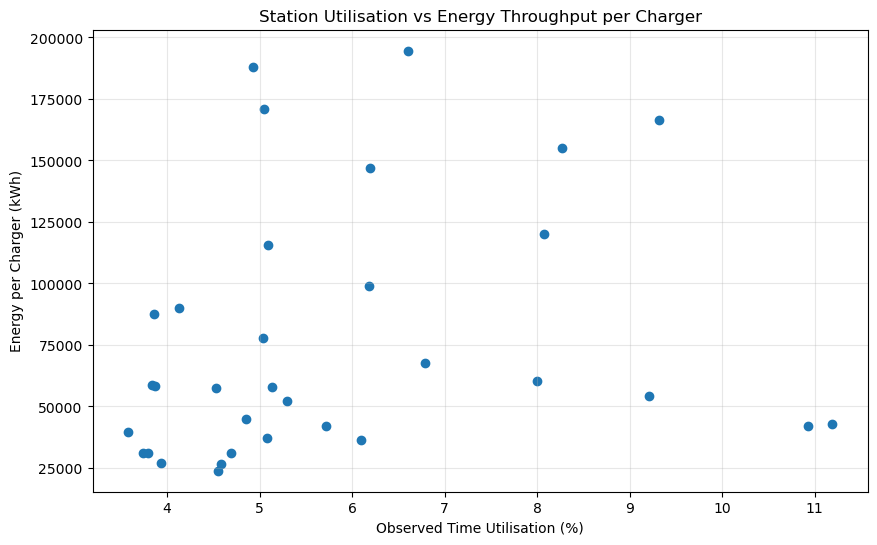

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    station_performance["avg_time_utilisation"],
    station_performance["energy_per_charger_kwh"]
)

plt.xlabel("Observed Time Utilisation (%)")
plt.ylabel("Energy per Charger (kWh)")
plt.title("Station Utilisation vs Energy Throughput per Charger")
plt.grid(True, alpha=0.3)

plt.show()

In [65]:
median_time_utilisation = (
    station_performance["avg_time_utilisation"].median()
)

median_energy_per_charger = (
    station_performance["energy_per_charger_kwh"].median()
)

print("Median time utilisation:", median_time_utilisation)
print("Median energy per charger:", median_energy_per_charger)

Median time utilisation: 5.081969420253581
Median energy per charger: 57864.59999999999


In [66]:
def classify_station(row):
    high_time = row["avg_time_utilisation"] >= median_time_utilisation
    high_energy = row["energy_per_charger_kwh"] >= median_energy_per_charger

    if high_time and high_energy:
        return "High Utilisation / High Throughput"
    elif high_time and not high_energy:
        return "High Utilisation / Lower Throughput"
    elif not high_time and high_energy:
        return "Lower Utilisation / High Throughput"
    else:
        return "Lower Utilisation / Lower Throughput"


station_performance["performance_profile"] = (
    station_performance.apply(classify_station, axis=1)
)

In [67]:
station_performance[
    [
        "station_id",
        "chargers",
        "total_sessions",
        "total_energy_kwh",
        "avg_time_utilisation",
        "energy_per_charger_kwh",
        "performance_profile"
    ]
].sort_values(
    "energy_per_charger_kwh",
    ascending=False
).head(15)

,station_id,chargers,total_sessions,total_energy_kwh,avg_time_utilisation,energy_per_charger_kwh,performance_profile
5,STN_006,4,15045,778478.1,6.604464,194619.5250,High Utilisation / High Throughput
1,STN_002,5,15276,940999.0,4.927344,188199.8000,Lower Utilisation / High Throughput
7,STN_008,5,15154,854549.0,5.045335,170909.8000,Lower Utilisation / High Throughput
6,STN_007,4,15218,666315.7,9.316130,166578.9250,High Utilisation / High Throughput
0,STN_001,4,15162,620951.6,8.265729,155237.9000,High Utilisation / High Throughput
2,STN_003,5,15321,733802.6,6.189524,146760.5200,High Utilisation / High Throughput
13,STN_014,4,10161,480807.6,8.076201,120201.9000,High Utilisation / High Throughput
11,STN_012,5,10231,578262.8,5.095474,115652.5600,High Utilisation / High Throughput
16,STN_017,5,10289,494681.8,6.178731,98936.3600,High Utilisation / High Throughput
3,STN_004,8,15121,720723.5,4.126212,90090.4375,Lower Utilisation / High Throughput


In [68]:
profile_counts = (
    station_performance["performance_profile"]
    .value_counts()
    .reset_index()
)

profile_counts.columns = [
    "performance_profile",
    "station_count"
]

profile_counts

,performance_profile,station_count
0,High Utilisation / High Throughput,10
1,Lower Utilisation / Lower Throughput,9
2,Lower Utilisation / High Throughput,7
3,High Utilisation / Lower Throughput,7


In [69]:
profile_counts["percentage"] = (
    profile_counts["station_count"]
    / profile_counts["station_count"].sum()
) * 100

profile_counts

,performance_profile,station_count,percentage
0,High Utilisation / High Throughput,10,30.303030
1,Lower Utilisation / Lower Throughput,9,27.272727
2,Lower Utilisation / High Throughput,7,21.212121
3,High Utilisation / Lower Throughput,7,21.212121


In [70]:
from pathlib import Path

analysis_dir = Path("analysis")
analysis_dir.mkdir(exist_ok=True)

print("Analysis folder ready:", analysis_dir)

Analysis folder ready: analysis


In [71]:
charger_output = final_charger_performance[
    [
        "charger_id",
        "station_id",
        "charger_type",
        "max_power_kW",
        "total_sessions",
        "total_charging_hours",
        "unique_charging_hours",
        "total_energy_kwh",
        "avg_delivered_power_kW",
        "capacity_utilisation_pct",
        "observed_hours",
        "observed_time_utilisation_pct"
    ]
].copy()

In [72]:
station_output = station_performance[
    [
        "station_id",
        "chargers",
        "total_sessions",
        "total_energy_kwh",
        "avg_time_utilisation",
        "avg_capacity_utilisation",
        "energy_per_charger_kwh",
        "sessions_per_charger",
        "performance_profile"
    ]
].copy()

In [73]:
print("Charger table:", charger_output.shape)
print("Station table:", station_output.shape)

print("\nDuplicate chargers:", charger_output["charger_id"].duplicated().sum())
print("Duplicate stations:", station_output["station_id"].duplicated().sum())

print("\nMissing charger values:")
print(charger_output.isna().sum())

print("\nMissing station values:")
print(station_output.isna().sum())

Charger table: (199, 12)
Station table: (33, 9)

Duplicate chargers: 0
Duplicate stations: 0

Missing charger values:
charger_id                       0
station_id                       0
charger_type                     0
max_power_kW                     0
total_sessions                   0
total_charging_hours             0
unique_charging_hours            0
total_energy_kwh                 0
avg_delivered_power_kW           0
capacity_utilisation_pct         0
observed_hours                   0
observed_time_utilisation_pct    0
dtype: int64

Missing station values:
station_id                  0
chargers                    0
total_sessions              0
total_energy_kwh            0
avg_time_utilisation        0
avg_capacity_utilisation    0
energy_per_charger_kwh      0
sessions_per_charger        0
performance_profile         0
dtype: int64


In [74]:
charger_output.to_csv(
    analysis_dir / "charger_performance.csv",
    index=False
)

station_output.to_csv(
    analysis_dir / "station_performance.csv",
    index=False
)

print("Charger dataset saved.")
print("Station dataset saved.")

Charger dataset saved.
Station dataset saved.


# Final Conclusions

## Key Findings

- The analysis evaluated 199 chargers across 33 stations and 294,024 charging sessions.
- DC_300kW chargers achieved the highest average energy throughput per charger.
- DC_50kW chargers showed the highest observed time utilisation.
- Capacity utilisation remained relatively consistent across charger types at approximately 78–80%.
- Station performance changed when energy throughput was normalised by charger count.
- Station performance profiles showed that utilisation and throughput capture different operational characteristics.

## Limitations

- Charger installation dates were inconsistent with observed session timestamps.
- Overlapping sessions required interval merging to avoid overestimating charging time.
- The dataset does not provide reliable charger uptime, outage, or maintenance information.
- Observed time utilisation therefore represents charging activity within the observed session window rather than true physical availability.
- Performance profiles are relative classifications based on network medians and should not be interpreted as definitive business performance ratings.

## Final Takeaway

EV charging infrastructure performance should be evaluated using multiple complementary metrics, including energy throughput, observed time utilisation, capacity utilisation, and normalised performance per charger.